# Quickstart Guide

This tutorial provides a quick introduction to using QCMet for quantum computing benchmarks.

## Running a T1 Measurement
To run a benchmark in QCMet, two main things are required:
1. A benchmark, defining a specific set of circuits to be run on a device together with the analysis instructions
2. An interface to a device which is benchmarked.

Here we consider a simple T1 measurement. T1 is the relaxation time of a qubit - the time it takes for an excited state to decay to the ground state.

The easiest way to run the T1 benchmark on a device (here an emulator with noise) is as follows:

{'success': True, 'T1 (t/t_[1q_gate])': np.float64(5075.256427790081), 'fit': {'popt': array([9.94609119e-01, 5.07525643e+03]), 'pcov': array([[ 7.26036497e-05, -7.12521691e-01],
       [-7.12521691e-01,  1.24104618e+04]])}}


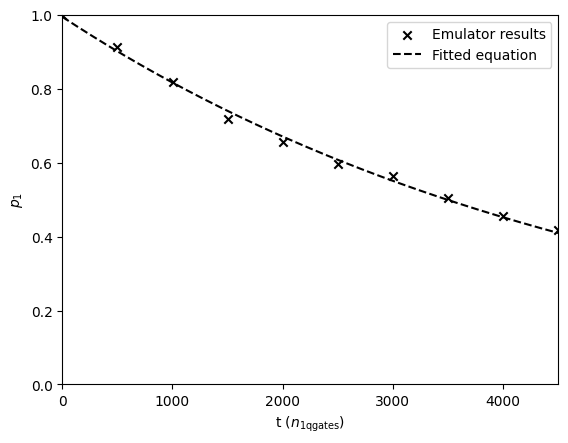

In [2]:
from qcmet import T1
from qcmet.devices import NoisySimulator
device = NoisySimulator()
t1_benchmark = T1()
result = t1_benchmark(device=device, num_shots=1000)
print(result)

## Workflow Summary

Under the hood, benchmarking in QCMet follows the same pattern:

1. **Create a device** (simulator or real hardware)
2. **Initialize the benchmark** with parameters
3. **Generate circuits** using `generate_circuits()`
4. **Run on device** using `run(device, num_shots=...)`
5. **Analyze results** using `analyze()` and `plot()`

This consistent interface makes it easy to swap between different benchmarks and devices.

Steps 3., 4., and 5. are bundled together via the __call__ function of the benchmark, allowing the above workflow.

The extended version of the above looks as follows (giving more fine-grained control over the workflow):

{'success': True, 'T1 (t/t_[1q_gate])': np.float64(5047.861299601484), 'fit': {'popt': array([9.95810541e-01, 5.04786130e+03]), 'pcov': array([[ 5.16389414e-05, -5.01290859e-01],
       [-5.01290859e-01,  8.64817566e+03]])}}


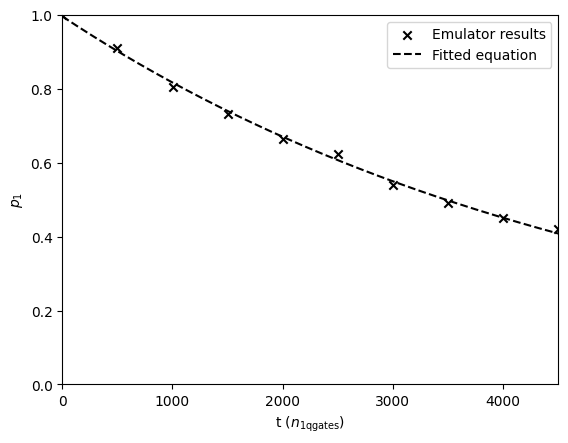

In [3]:
device = NoisySimulator()
t1_benchmark = T1()
t1_benchmark.generate_circuits()
t1_benchmark.run(device, num_shots=1000)
t1_benchmark.analyze()

print(t1_benchmark.result)

# Optional plotting
t1_benchmark.plot();

## Running a Collection of (Different) Benchmarks

Using `BenchmarkCollection`, (different) benchmarks can be conveniently collected together and run in one go. The workflow for `BenchmarkCollection` is the same.

{'T1_qubit0': {'success': True, 'T1 (t/t_[1q_gate])': np.float64(4921.90883298913), 'fit': {'popt': array([1.00080094e+00, 4.92190883e+03]), 'pcov': array([[ 1.04735996e-04, -9.67076438e-01],
       [-9.67076438e-01,  1.59683063e+04]])}}, 'T1_qubit1': {'success': True, 'T1 (t/t_[1q_gate])': np.float64(4935.735020047913), 'fit': {'popt': array([1.00221630e+00, 4.93573502e+03]), 'pcov': array([[ 7.77027260e-05, -7.20040546e-01],
       [-7.20040546e-01,  1.19235786e+04]])}}, 'T2_qubit0': {'success': True, 'T2 (t/t_[1q_gate])': np.float64(4974.891341400257), 'method': 'hahn', 'fit': {'popt': array([3.66603319e-01, 4.97489134e+03, 6.32647308e-01]), 'pcov': array([[ 6.03545864e-02,  9.95477236e+02, -6.10321150e-02],
       [ 9.95477236e+02,  1.64839049e+07, -1.00735693e+03],
       [-6.10321150e-02, -1.00735693e+03,  6.17271195e-02]])}}, 'T2_qubit1': {'success': True, 'T2 (t/t_[1q_gate])': np.float64(14195134.618335167), 'method': 'hahn', 'fit': {'popt': array([ 9.24977699e+02,  1.41951346e

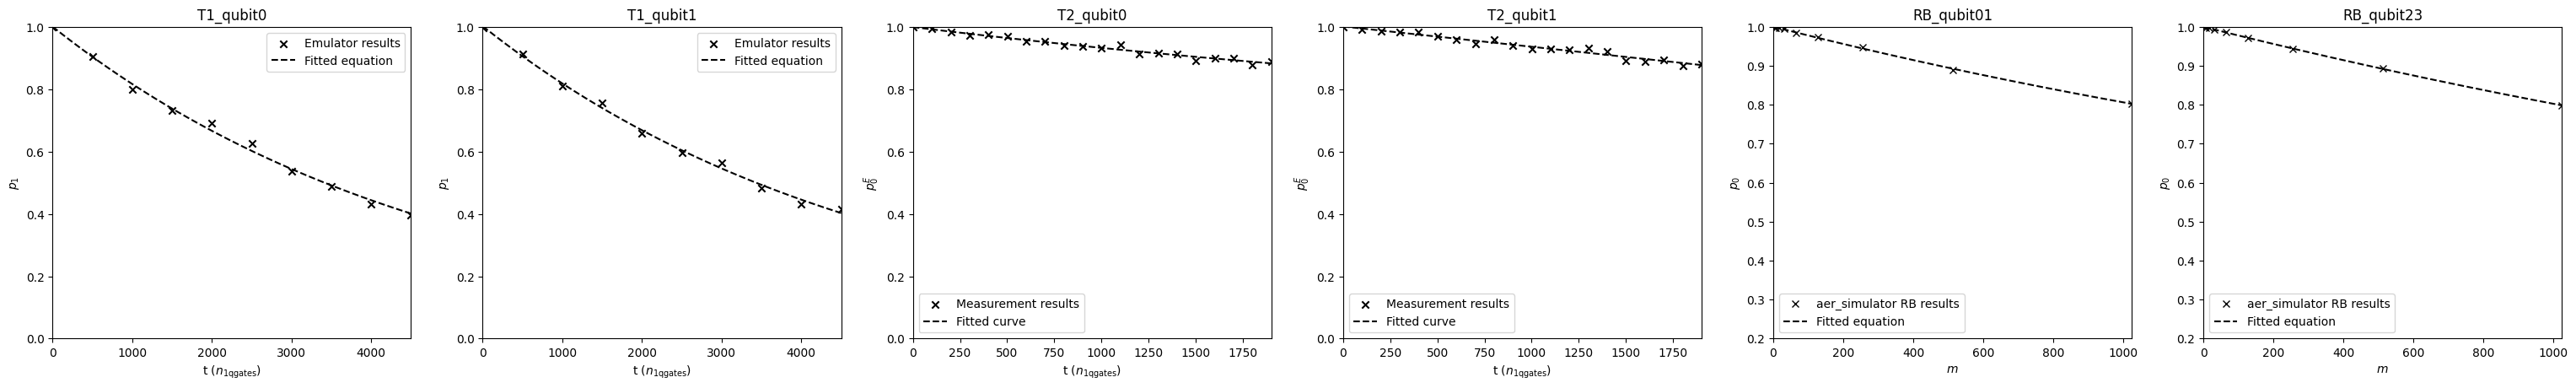

In [4]:
from qcmet import BenchmarkCollection, T2, CliffordRB

t1_benchmark_1 = T1(qubit_index=0)
t1_benchmark_2 = T1(qubit_index=1)
t2_benchmark_1 = T2(qubit_index=0)
t2_benchmark_2 = T2(qubit_index=1)
rb_benchmark_1 = CliffordRB([2 ** n for n in range(1, 11)], qubits=[0, 1])
rb_benchmark_2 = CliffordRB([2 ** n for n in range(1, 11)], qubits=[2, 3])

collection = BenchmarkCollection({"T1_qubit0": t1_benchmark_1, "T1_qubit1": t1_benchmark_2,
                                  "T2_qubit0": t2_benchmark_1, "T2_qubit1": t2_benchmark_2,
                                  "RB_qubit01": rb_benchmark_1, "RB_qubit23": rb_benchmark_2})

# Using the same workflow
collection.generate_circuits()

"""
Now there are two different ways to run the circuits

When passing in a list of shot number for num_shots, all the circuits are submitted
to the device one after the other and each benchmark is run separately with the
corresponding number of shots:
"""
# collection.run(device, num_shots=[1000 for _ in range(6)])

"""
When passing in a single number for num_shots, all circuits are merged and submitted
as one batch
"""
collection.run(device, num_shots=1000)

collection.analyze()
collection.plot()

# Or directly use the call function
# collection(device, num_shots=1000)

print(collection.result)

## Running a Collection of Benchmarks in Parallel

By setting the parameter `fuse_circuits` to `True`, the circuits within a collection can be fused into larger circuits composed of the original circuits from each sub-benchmark. In this way, the total number of circuits to be run can be reduced by a factor equal to the number of benchmarks.

This has the following assumptions:
- Each sub-benchmark must act on disjoint qubit indices, i.e., they cannot have circuits that operate on the same qubits.
- The first circuits within each sub-benchmark will be fused into one larger circuit, then the second circuits, etc.
- The number of shots must be the same for all benchmarks, i.e., the `run` function of the collection expects only one number for the `num_shots` parameter. 


Measurement outcomes of the fused circuits will be automatically distributed back to the sub-benchmarks, so that the rest of the workflow stays the same. 


{'T1_qubit0': {'success': True, 'T1 (t/t_[1q_gate])': np.float64(4899.547121844393), 'fit': {'popt': array([1.00067531e+00, 4.89954712e+03]), 'pcov': array([[ 1.71029877e-05, -1.56664780e-01],
       [-1.56664780e-01,  2.56921023e+03]])}}, 'T1_qubit1': {'success': True, 'T1 (t/t_[1q_gate])': np.float64(4998.327755121612), 'fit': {'popt': array([1.00123576e+00, 4.99832776e+03]), 'pcov': array([[ 3.50758950e-05, -3.32745884e-01],
       [-3.32745884e-01,  5.62327019e+03]])}}}


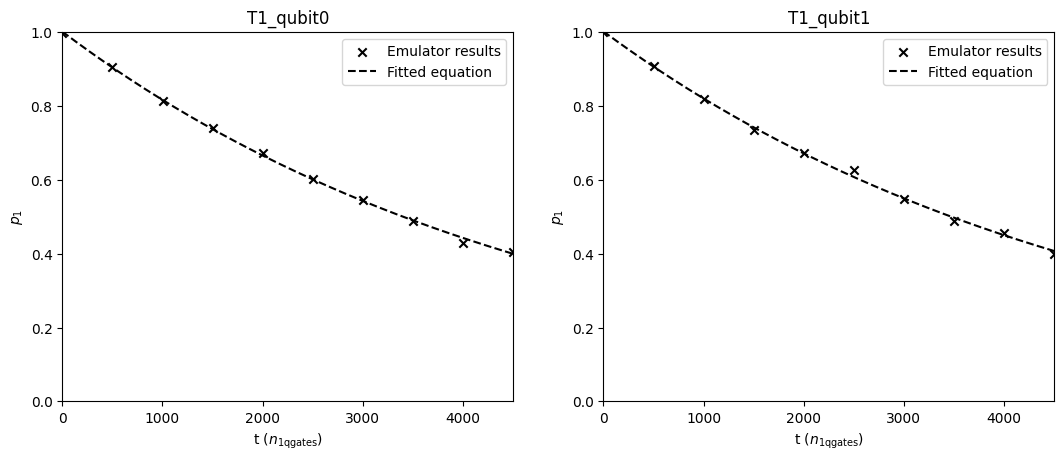

In [5]:
collection = BenchmarkCollection({"T1_qubit0": t1_benchmark_1, "T1_qubit1": t1_benchmark_2}, fuse_circuits=True)

collection.generate_circuits()
collection.run(device, num_shots=1000)
collection.analyze()
collection.plot()

# Or directly use the call function
# collection(device, num_shots=1000)

print(collection.result)

## Implemented benchmarks

QCMet ships various benchmarking protocols for (digital) quantum computers:

### Qubit Quality Metrics
- **T1**: Relaxation time (energy decay)
- **T2**: Relaxation time (dephasing)
- **Idle Qubit Oscillation Frequency**: Non-Markovian noise induced coherence revivals

### Gate Execution Quality Metrics
- **Clifford RB**: Average gate error rate
- **Interleaved RB**: Specific gate error rate
- **Over/Under Rotation**: Systematic rotation errors
- **Cycle Benchmarking**: Average fidelity of a repeated layer
- **Gate Set Tomography**: Full characterization of process fidelity

### Circuit Execution Quality Metrics
- **Quantum Volume**: Holistic circuit complexity measure
- **Mirrored Circuits**: Target circuit performance benchmark
- **Upper Bound on Variation Distance**: Quantum accreditation protocol

### Well-studied Task Execution Quality Metrics
- **QFT**: Quantum Fourier Transform fidelity
- **VQE**: Energy expectation value reproducibility
- **QScore**: Metric based on using QAOA for a MaxCut problem 
- **Hamiltonian Simulation**: Ability to perform Hamiltonian dynamics
